In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full.csv")

## look at internet fixes v002

In [3]:
def apply_technical_exclusion_criteria(df: pd.DataFrame) -> pd.DataFrame:
    """
    - We exclude all negotiations where the current second of a player is different from the full bargaining time by more than 4 seconds. 
    - We exclude all negotiations where there was both acceptance and termination
    """
    
    df_out = df.copy()
    
    # Criterion 1: time discrepancy > 4s
    time_mask = (df_out["current_second"] - df_out["bargaining_time_full_sec"]).abs() > 4
    bad_time_ids = df_out.loc[time_mask, "negotiation_id"].unique()
    print(f"Excluding {len(bad_time_ids)} negotiations for time discrepancy > 4s")
    
    # Criterion 2: both acceptance and termination present
    both_mask = (
        (df_out["acceptance_time_raw"].notna()
        & df_out["termination_time_raw"].notna()) 

    )
    bad_both_ids = df_out.loc[both_mask, "negotiation_id"].unique()
    print(f"Excluding {len(bad_both_ids)} negotiations for both acceptance and termination")
    
    # Combine all negotiation_ids to exclude
    exclude_ids = set(bad_time_ids) | set(bad_both_ids)
    
    # Filter them out
    filtered_df = df_out.loc[~df_out["negotiation_id"].isin(exclude_ids)].reset_index(drop=True)
    return filtered_df

In [4]:
excluded_df = apply_technical_exclusion_criteria(df)

Excluding 17 negotiations for time discrepancy > 4s
Excluding 32 negotiations for both acceptance and termination


In [5]:
# Calculate the difference by group
diff_by_group = (
    excluded_df
    .groupby(['session_id', 'round', 'group_id_in_round'])['cumulated_TA_costs']
    .agg(lambda x: x.max() - x.min())
)

# Filter groups where the difference exceeds 0.16
large_diff_mask = diff_by_group > 0.16
large_diff_groups = diff_by_group[large_diff_mask].index

# Filter the original dataframe to only include these groups
filtered_df = excluded_df.set_index(['session_id', 'round', 'group_id_in_round']).loc[large_diff_groups].sort_values('negotiation_id').reset_index()

## Look at internet fixes

In [4]:
df["time_discrepancy"] = df["current_second"] - df["bargaining_time_full_sec"]

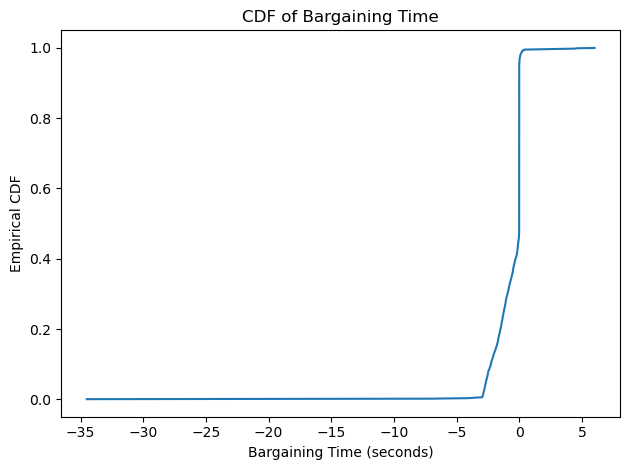

In [5]:
# Ensure you have a column to plot – here we use 'bargaining_time_full_sec'
data = df['time_discrepancy'].dropna()

# Sort data and compute empirical CDF
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Plot
plt.figure()
plt.plot(sorted_data, cdf)
plt.xlabel('Bargaining Time (seconds)')
plt.ylabel('Empirical CDF')
plt.title('CDF of Bargaining Time')
plt.tight_layout()
plt.show()

In [9]:
error_count = df[abs(df["time_discrepancy"]) > 3].shape[0]
print(f"Number of errors in time discrepancy: {error_count}")
error_df = df.loc[abs(df["time_discrepancy"]) > 3, ["participant_code", "bargaining_time_full_sec", "current_second", "time_discrepancy", "offer_amount_list", "offer_time_list", "bargaining_outcome", "group_id_in_round", "accepted_by_id_in_group", "terminated_by_id_in_group", "id_in_group"]]

Number of errors in time discrepancy: 24


## TIme Fix for first two sessions based on acceptance time

In [ ]:
special_sessions_mask = (
    df["session_id"].isin({"o1rrqa15", "1a8klj6g"}) &
    ((df["accepted_by_id_in_group"] == df["id_in_group"]) | (df["terminated_by_id_in_group"] == df["id_in_group"]))
)

In [ ]:
filter_df = df[special_sessions_mask].copy()
filter_df["time_fix"] = filter_df["cumulated_TA_costs"] / 0.05

In [ ]:
view = filter_df[["time_fix", "acceptance_time_sec", "termination_time_sec"]]